Title: SEM.ipynb

Purpose: 

Author: Onno Nennecke on 06.03.2025 Modified: 17.03.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [3]:
# Load wind height data
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')

In [4]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']

In [5]:
# Load climate data
ESM = 'CESM2' 
run = 'r4i1p1f1'# 'r1i1p1f1'
scenario = 'ssp370' # 'historical'
MIP = 'ScenarioMIP' # CMIP
version = 'v20200528' # 'v20190308'

# List of variables
variables = ['sfcWind', 'rsds', 'tas', 'tasmax']

# Preprocess function to apply spatial filter directly at load time
# def preprocess(ds):
#     return ds.sel(lat=slice(45, 60), lon=slice(5, 17))

# List to hold individual datasets (one for each variable)
ds_list = []

# Load each variable and apply filtering
for variable in variables:
    path = f'/climca/data/CMIP6/{MIP}/*/{ESM}/{scenario}/{run}/day/{variable}/*/{version}/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
    
    # Open with preprocessing (spatial filtering)
    nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
    
    # Keep only the desired variable, but retain Dataset structure
    nc = nc[[variable]]

    # Filter to only winter months (October to March)
    # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    
    nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

    # Append to list for later merging
    ds_list.append(nc)

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

if ds_list[2]['tas'].units == 'K':
    clim_ds['tas'] = clim_ds['tas'] - 273.15
if ds_list[3]['tasmax'].units == 'K':
    clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

In [6]:
# Regrid the combined dataset
combined_ds = grid_func.regrid(clim_ds)
# combined_ds

## Wind energy production

In [7]:
# Define variables (all in the config file)
'''
alpha_on = 1/7 # Roughness parameter onshore
alpha_off = 0.11 # Roughness parameter offshore
ref_height = 10 # Height of wind data
v_cutin = 3.5 # Minimum wind speed to start producing power
v_cutout = 25 # Maximum wind speed to produce power
v_rated = 13 # Wind speed at which the turbine produces maximum power

# hub_height_on = 80 # Approximation: Onshore 80 m --> Bad Approximation
# hub_height_off = 120 # Approximation: Offshore 120 m --> Bad Approximation
'''

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [8]:
wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, config.height_ref)

In [9]:
combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']

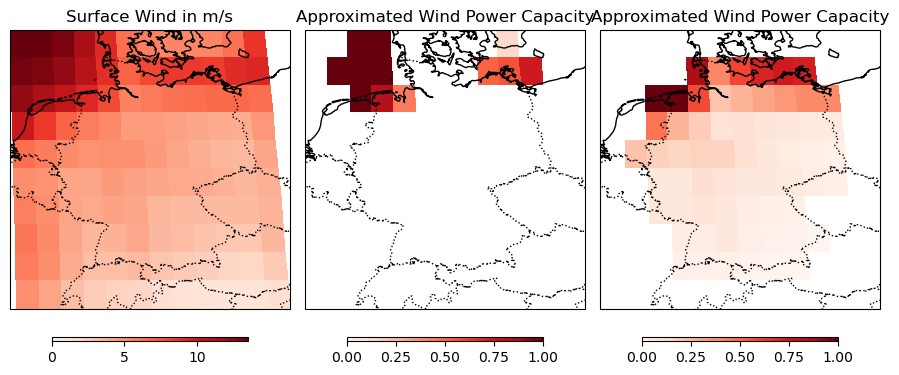

In [10]:
# Just a plot of one timestep of the wind and the approximated on- and offshore wind power capacity

lon_edges = combined_ds['lon'].values - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 1

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['sfcWind'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wepot_off['wind_off_pot'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wepot_on['wind_on_pot'].isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')


plt.tight_layout()
plt.show()


In [11]:
weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)

In [12]:
combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']

## Solar energy production

In [13]:
sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['sfcWind'])

In [14]:
combined_ds['solar_pot'] = sepot

In [15]:
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot.where(grid_solar > 0)

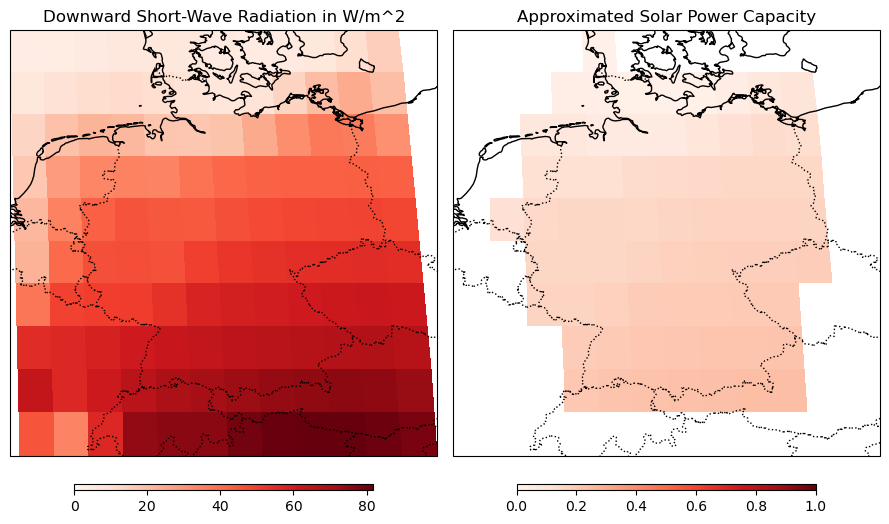

In [16]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity

# '''
lon_edges = combined_ds['lon'].values - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 1 #29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['rsds'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

In [17]:
seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)

In [18]:
combined_ds['solar_prod'] = seprod

## Demand

In [19]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

In [20]:
# Calculate weighted sum

weighted_temp_list = []
for y in np.unique(combined_ds['tas']["time.year"].values):
    # print(y)
    ds_weigh_temp_0 = xr.Dataset()
    ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
    weighted_temp_list.append(ds_weigh_temp_0)
    
ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
# ds_weighted_temp
 

In [21]:
# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

# Calculate demand
demand_ds = demand.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))

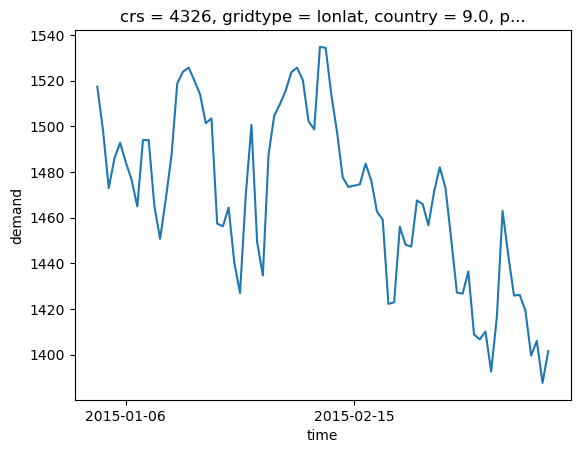

In [22]:
demand_ds['demand'][0:80].plot()

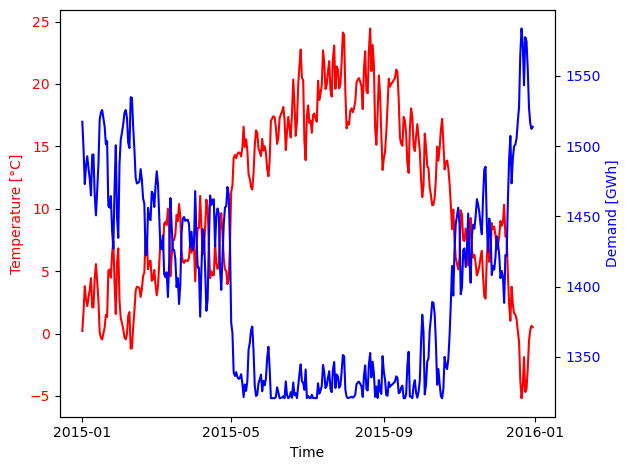

In [23]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots()

a = 0
b = 364

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.show()

## Combination

1. Idea: Calculate Grids with total energy production
2. Idea: Calculate a timeseries for each energy production

In [24]:
timeseries_ds = demand_ds.copy()

In [25]:
timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000

In [26]:
timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

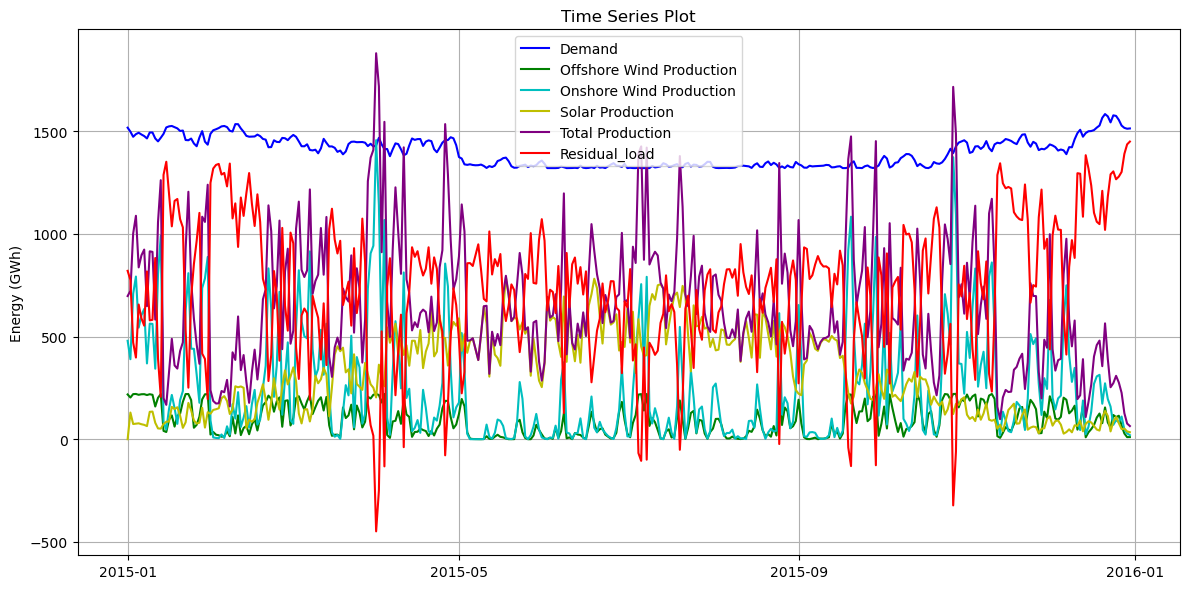

In [27]:

# Define your slice (adjust these to your desired time range)
a = 0
b = 364

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b]
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

